# Plotting synthetic datasets notebook

This notebook reproduces the residual plots for the synthetic datasets.


In [1]:
from pathlib import Path
import importlib.util
import pickle
import yaml

repo_root = Path.cwd()
if not (repo_root / "results").exists():
    repo_root = repo_root.parent

plotting_path = repo_root / "src" / "adaptive_low_rank" / "plotting.py"
spec = importlib.util.spec_from_file_location("adaptive_low_rank_plotting", plotting_path)
plotting = importlib.util.module_from_spec(spec)
spec.loader.exec_module(plotting)


def load_results(results_dir):
    results_dir = Path(results_dir)
    with (results_dir / "results.pkl").open("rb") as file:
        results = pickle.load(file)
    with (results_dir / "config.yml").open() as file:
        config = yaml.safe_load(file)
        dataset_name = config["dataset"]
    return results, dataset_name


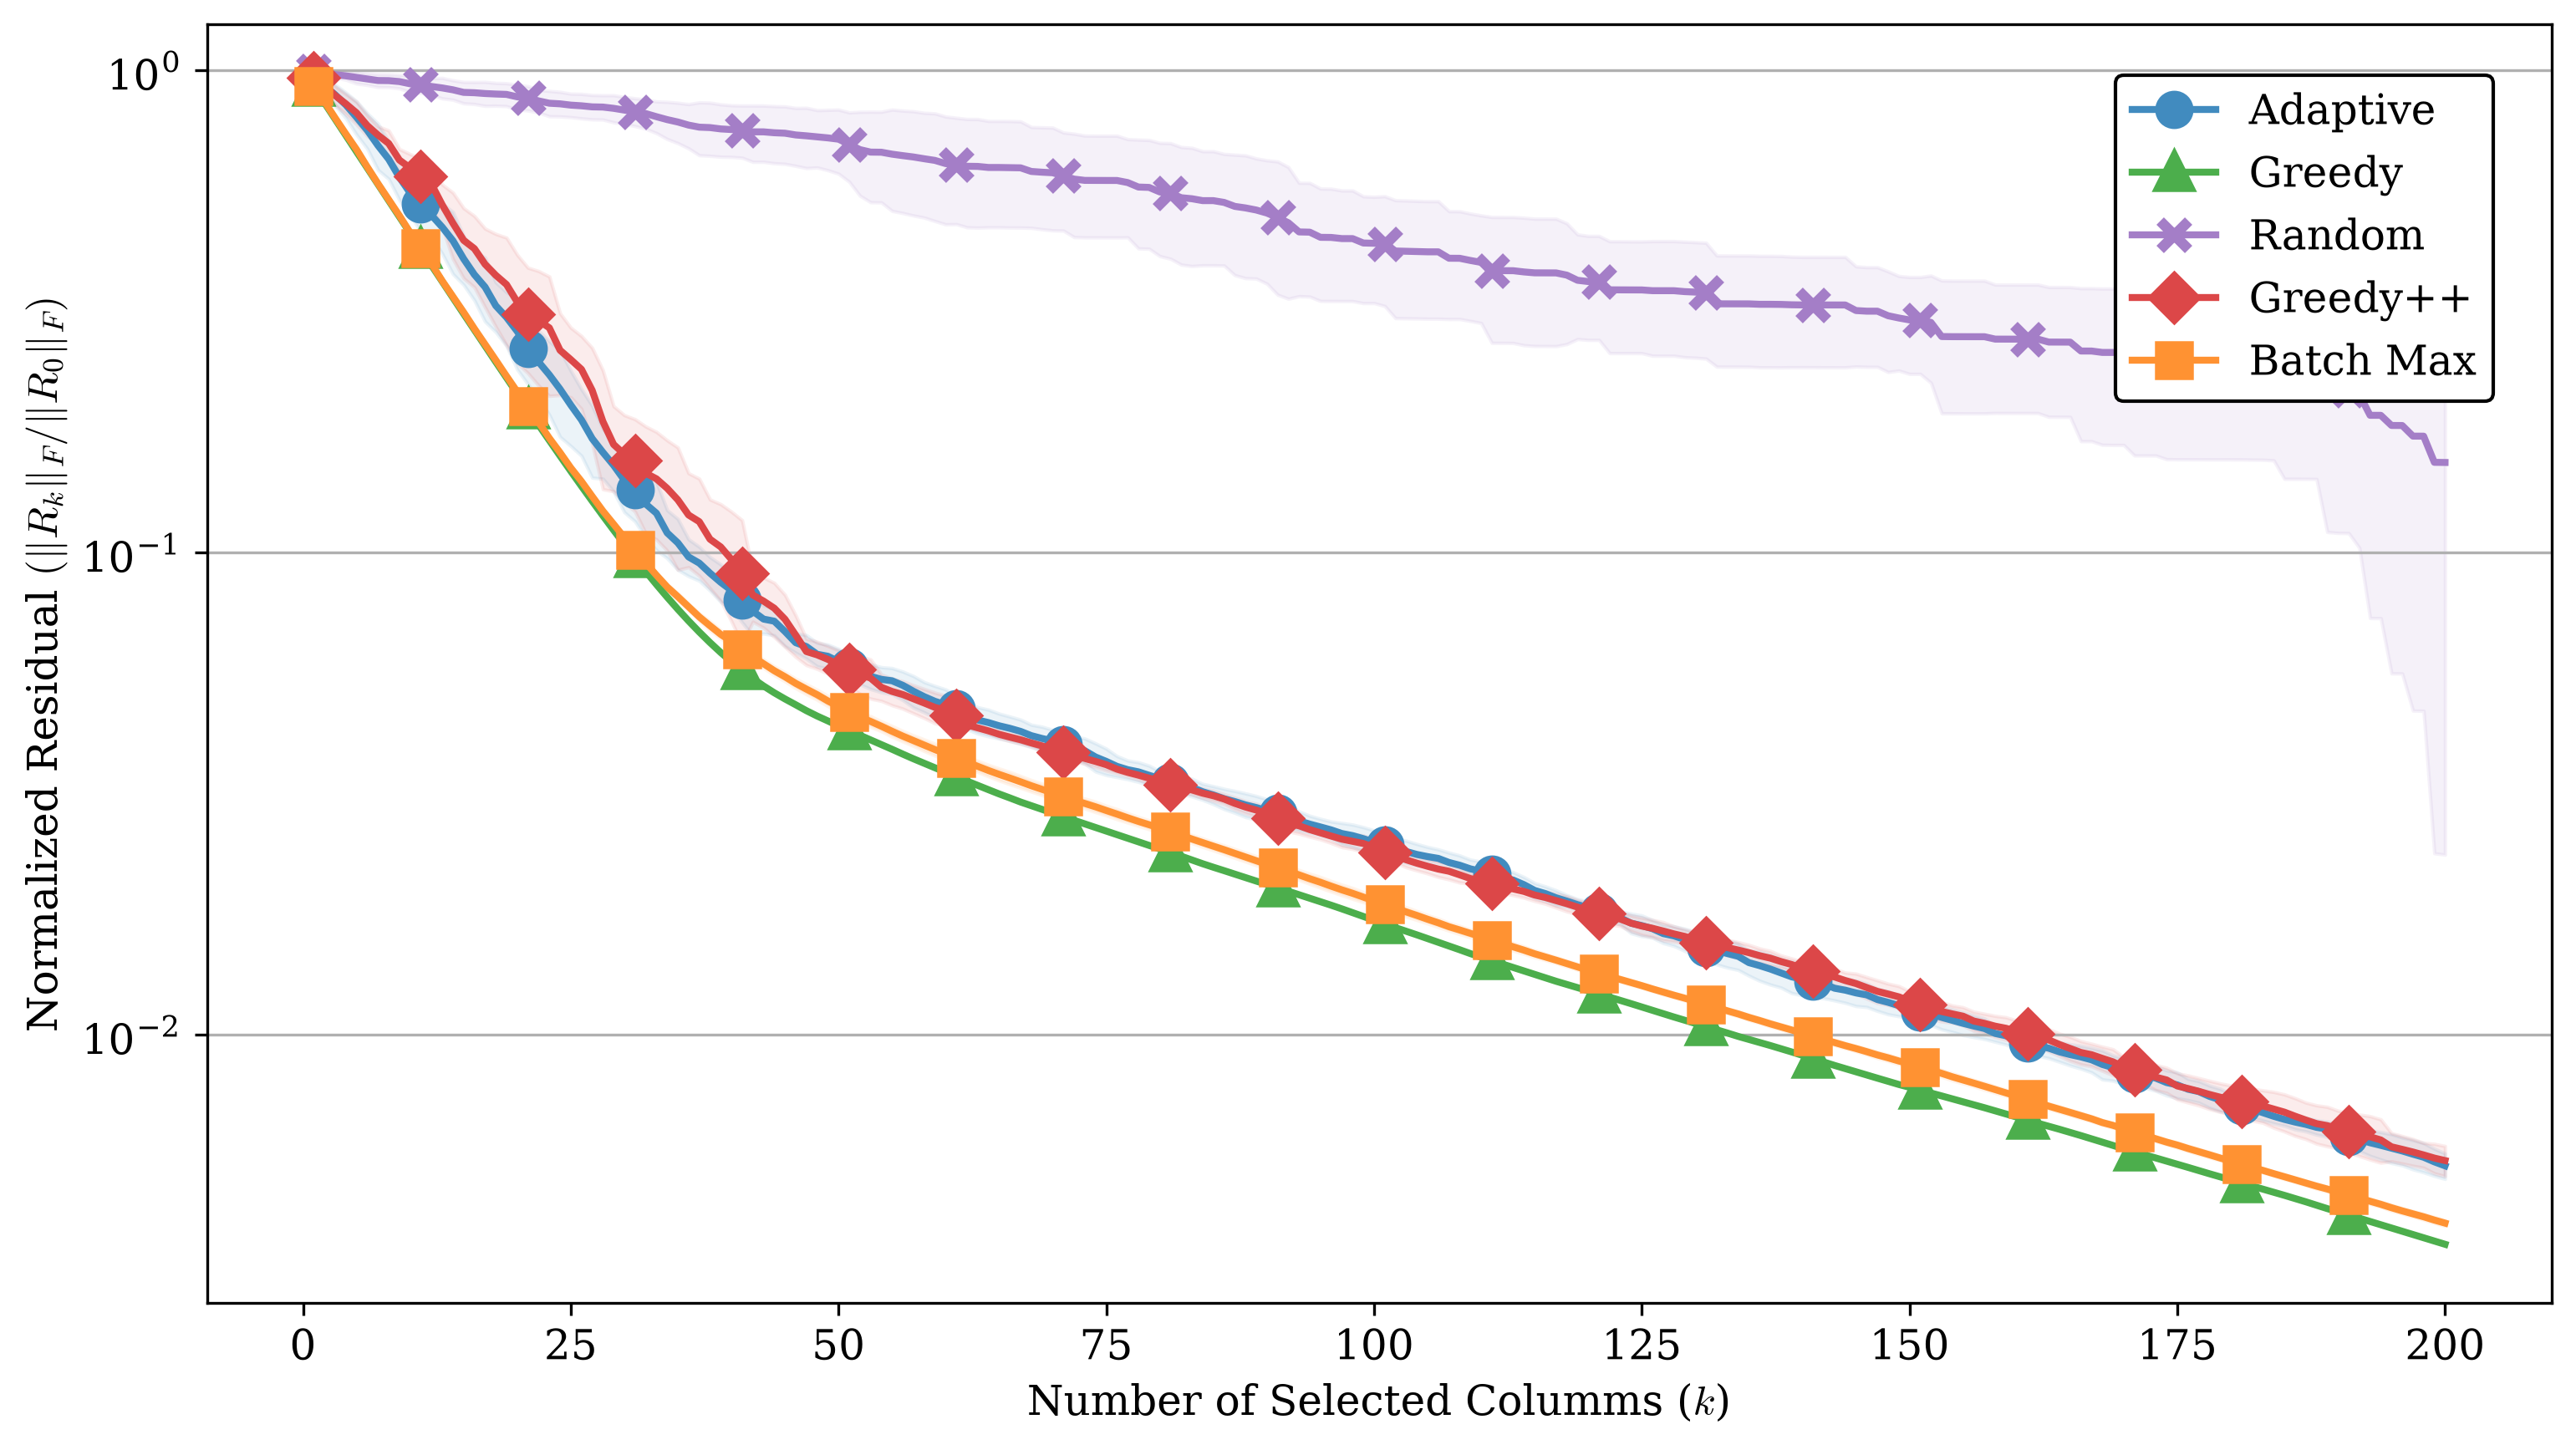

In [2]:
results, experiment_name = load_results(repo_root / "results" / "orthogonal_tubes_1")
plotting.plot_residuals(
    results,
    output_dir=repo_root / "figures",
    name=experiment_name,
    compute_optimal=False,
)


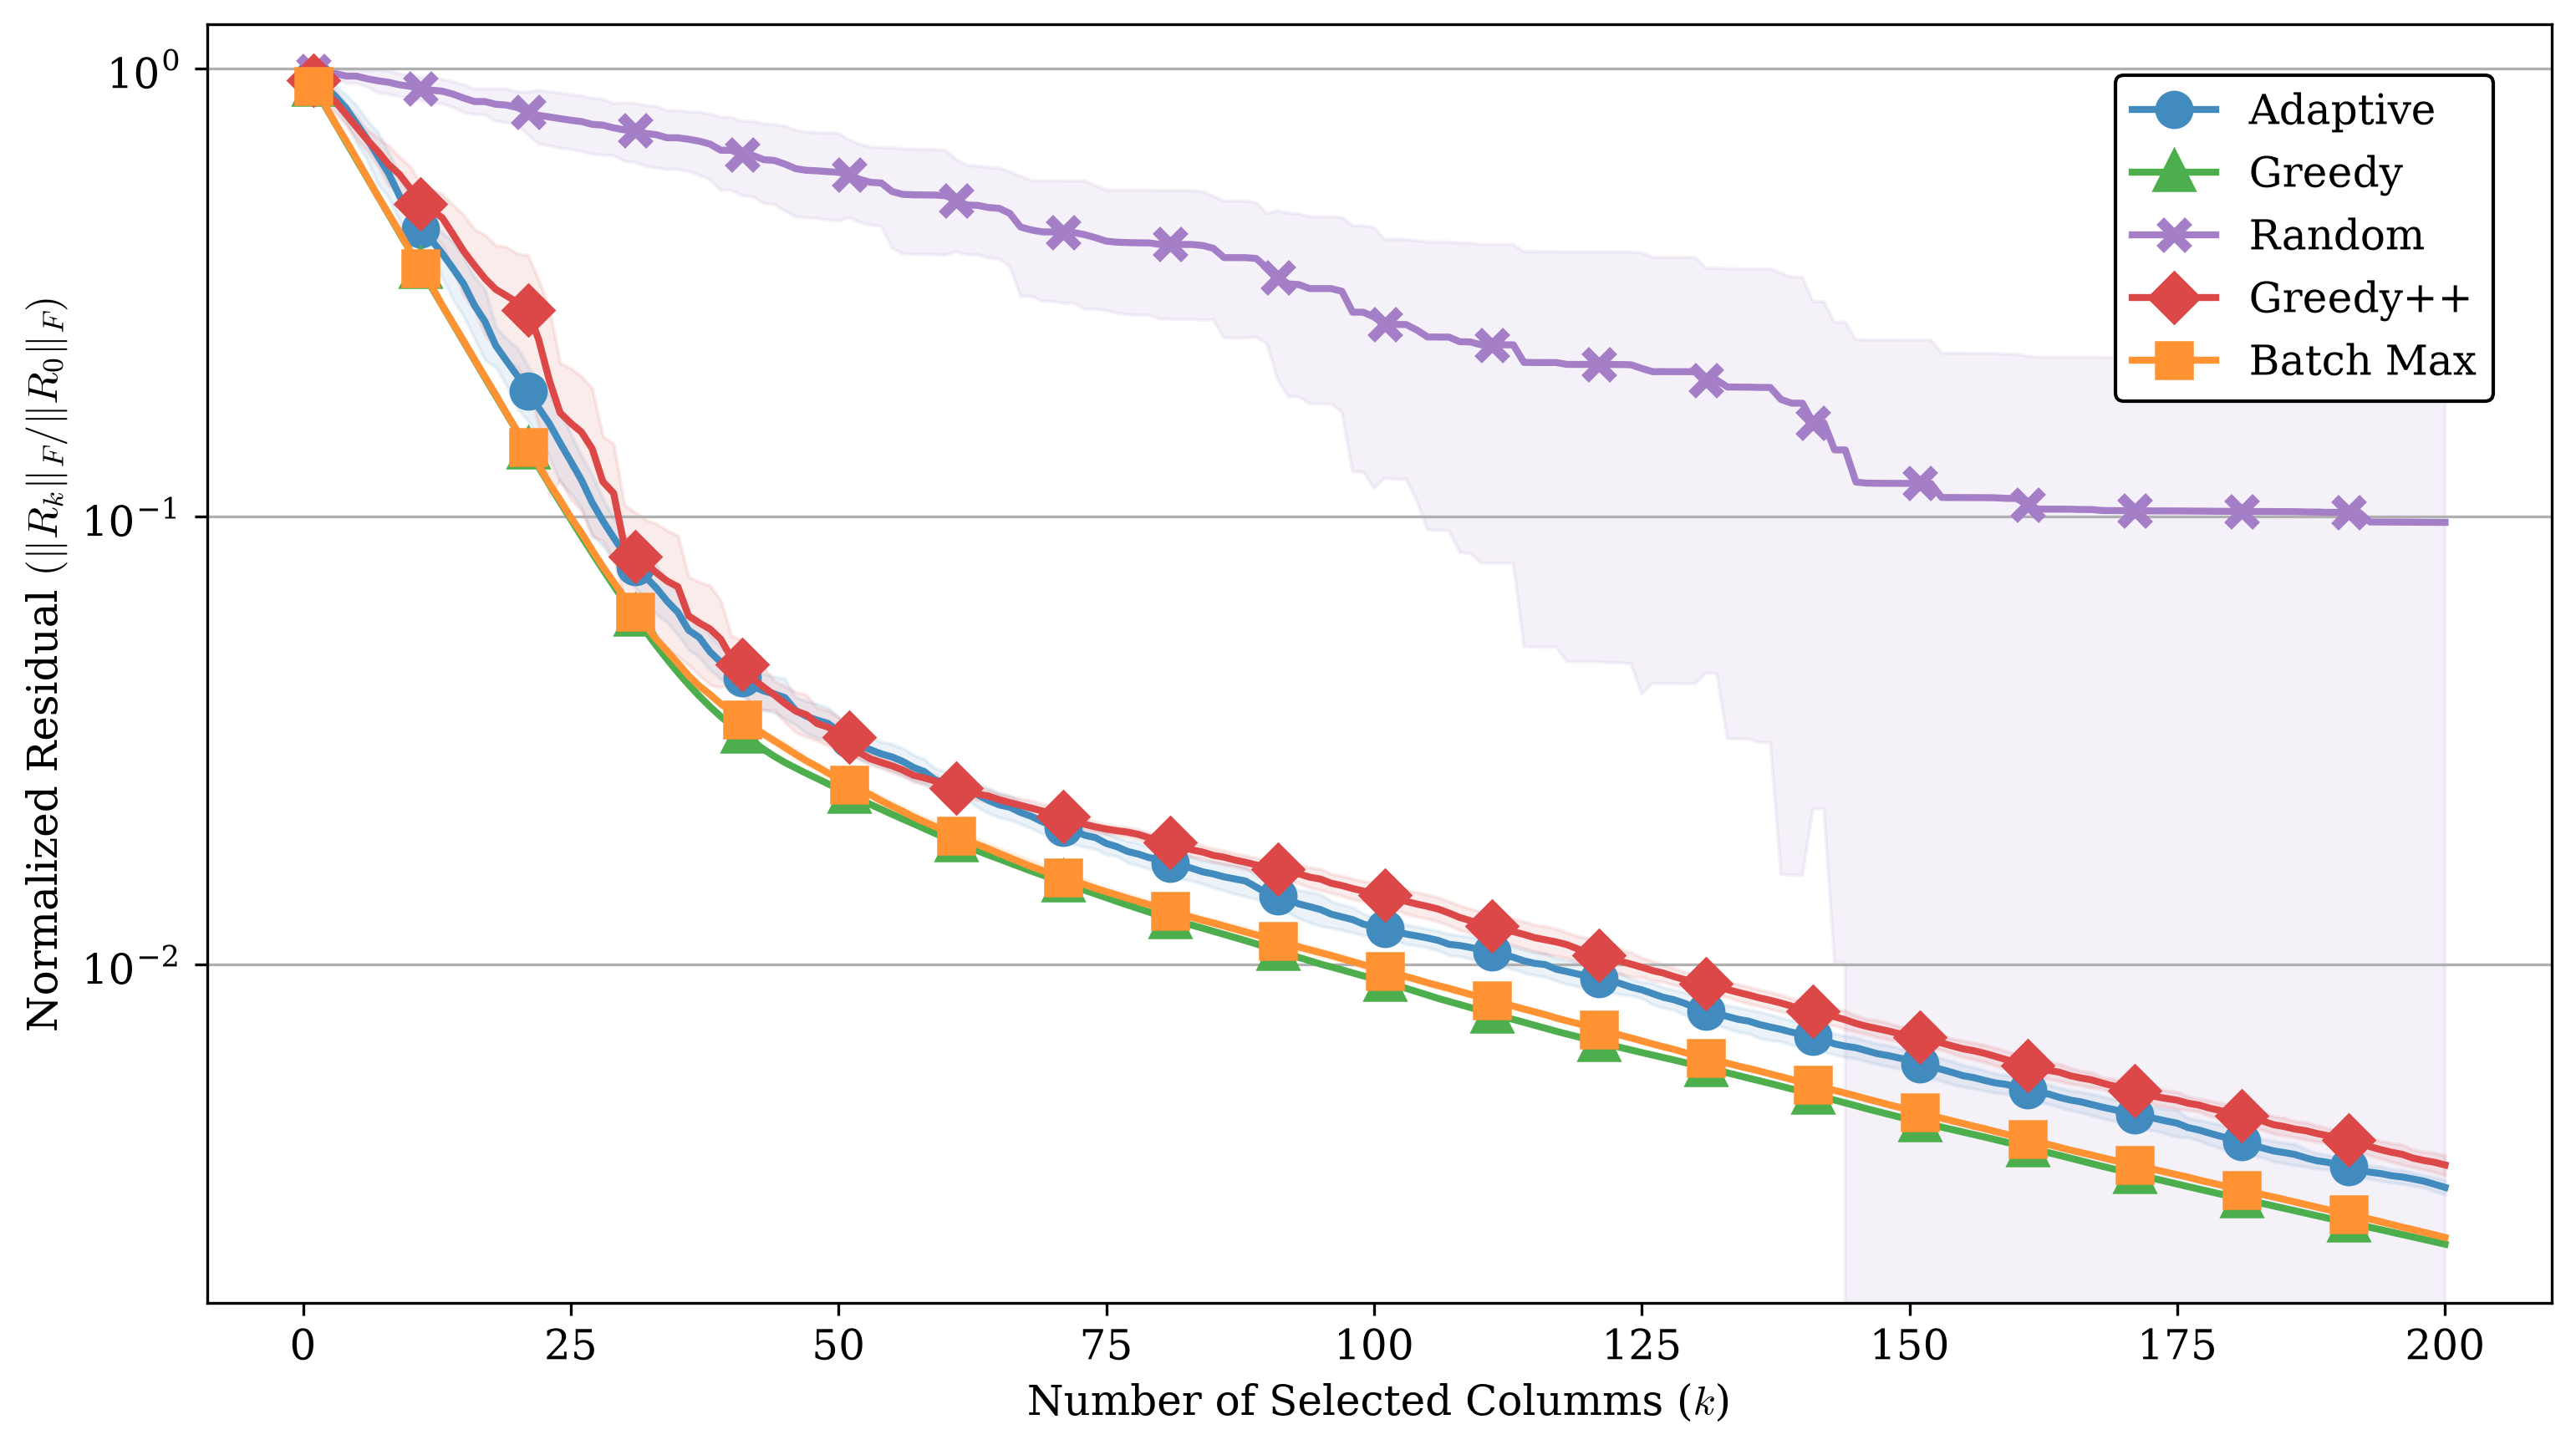

In [3]:
results, experiment_name = load_results(repo_root / "results" / "orthogonal_tubes_2")
plotting.plot_residuals(
    results,
    output_dir=repo_root / "figures",
    name=experiment_name,
    compute_optimal=False,
)
